# **Lab 4 - Retea neuronala convolutionala pentru recunoastere categorii de imbracaminte/incaltaminte**

Ne propunem sa construim o retea neuronala convolutionala care sa identifice categorii de imbracaminte/incaltaminte plecand de la niste imagini. Reteaua se va antrena pe o colectie de imagini de obiecte cu dimensiunea 28x28 pixeli si va primi ca multime de testare imagini de acelasi tip. Va recunoaste obiectele din imaginile din multimea de testare.

Colectia de date este inclusa in **tf.keras.datasets**.


In [ ]:
#!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/620.7 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/620.7 MB 149.5 MB/s eta 0:00:05
   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/620.7 MB 155.5 MB/s eta 0:00:04
   ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/620.7 MB 174.0 MB/s eta 0:00:04
   ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.9/620.7 MB 203.5 MB/s eta 0:00:03
   ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/620.7 MB 184.2 MB/s eta 0:00:04
   ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.8/620.7 MB 136.7 MB/s eta 0:00:05
   ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.8/620.7 MB 92.0 MB/s eta 0:00:07
   ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.9/620.7 MB 80.6 MB/s eta 0:00:08
   ━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/620.7 MB 117.6 MB/s eta 0:00:05
   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/620.7 MB 145.4 MB/s eta 0:00:04
   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/620.7 MB 131.1 MB/s eta 0:00:05
   ━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
#%restart_python

In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.14.1


In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Colectia FASHION_MNIST

este o colectie mare de date de imagini de obiecte de imbracaminte si incaltaminte.

Baza de date contine 60.000 de imagini in mt de training si 10.000 de imagini de testare.

## Semnificatia celor 10 valori de iesire
label_class = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
 'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot']


In [3]:
#incarcam baza de date
# https://www.tensorflow.org/api_docs/python/tf/keras/datasets

mnist = tf.keras.datasets.cifar10

(x_train, y_train), (x_test, y_test) = mnist.load_data()

170498071/170498071 [==============================] - 6s 0us/step


In [4]:
y_train.shape

(50000, 1)

In [5]:
y_train[0][0]
i=10
y_train[i][0]


4

In [9]:
label_class = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [10]:
label_class[y_train[i][0]]

'deer'

Prima imagine

In [11]:
x_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [12]:
x_train.shape

(50000, 32, 32, 3)

In [13]:
x_test.shape

(10000, 32, 32, 3)

In [14]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [15]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [ ]:
# semnificatia celor 10 valori de iesire
#label_class = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
# 'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

Primele 10 imagini

In [18]:
# Ce obiecte reprezinta primele 10 imagini
for i in range(10):
  print(label_class[y_train[i][0]])

frog
truck
truck
deer
automobile
automobile
bird
horse
ship
cat


Primul obiect

In [19]:
import matplotlib.pyplot as plt

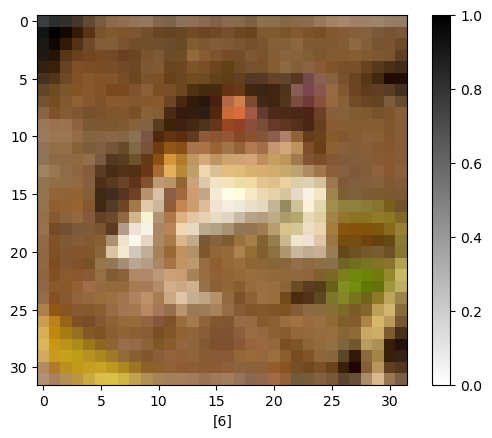

In [20]:
plt.figure()
plt.imshow(x_train[0], cmap=plt.cm.binary)
plt.xlabel(str(y_train[0]))
plt.colorbar()
plt.grid(False)
plt.show()

Primele 20 obiecte din  multimea de training.

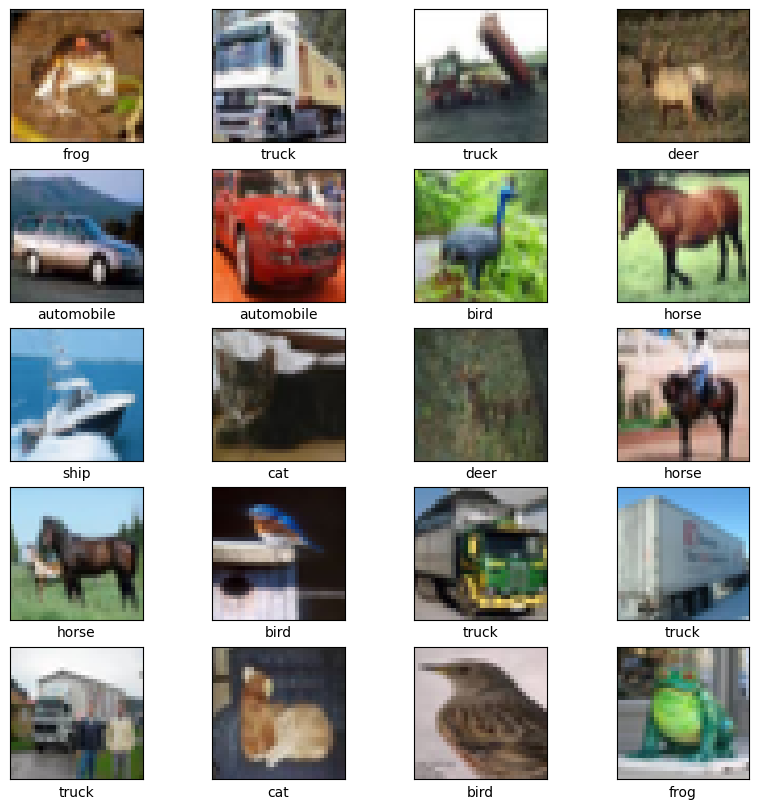

In [21]:
plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(label_class[y_train[i][0]])
plt.show()

Primele 20 obiecte din multimea de testare.

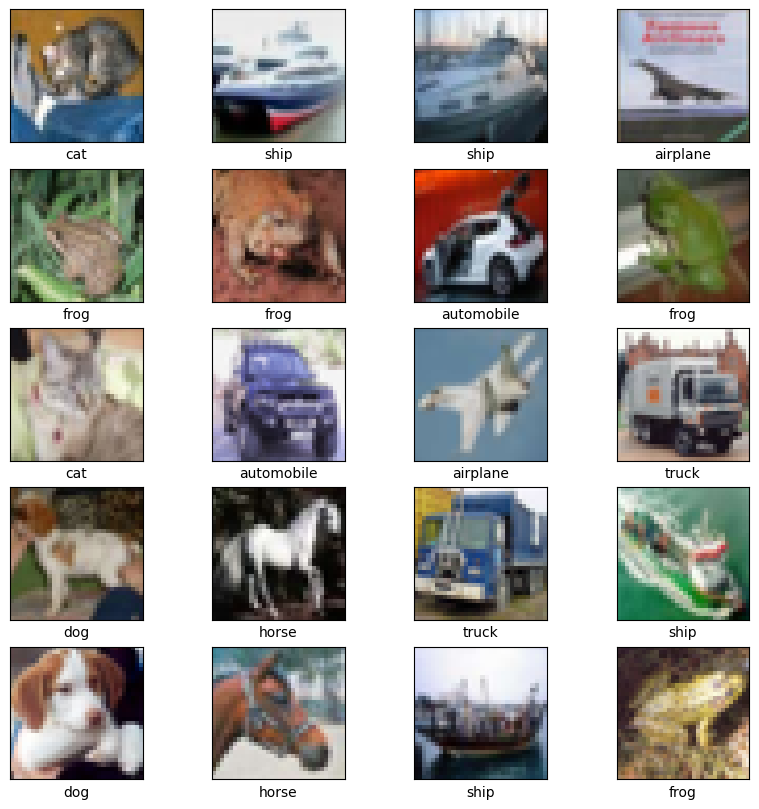

In [22]:
plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.xlabel(label_class[y_test[i][0]])
plt.show()

## **Construire model - retea neuronala convolutionala**

In [23]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(
        filters=32, # numarul de filtre
        kernel_size=(3, 3), # dimensiunea filtrului/convolutiei
        strides=(1, 1), # dimensiunea pasului
        padding='valid', # fara padding (fara bordura suplimentara)
        activation='relu',
        input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2), # dimensiunea filtrului de agregare
        strides=(2, 2) ), # pasul
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])


In [24]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 7200)              0         
                                                                 
 dense (Dense)               (None, 128)               921728    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 923914 (3.52 MB)
Trainable params: 923914 (3.52 MB)
Non-trainable params: 0 (0.00 Byte)
____________________

### **Compilarea modelului**

Alegem ca functie loss - entropia deoarece atributul tinta este discret si multiclass. Am explicat in Lab1_Curs_DL de ce alegem parametrul from_logits=True.

**adam** este tehnica de alegere a ratei de invatare.

In [25]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

### **Antrenarea modelului**

Se aplica functia **fit** pe multimea de training si cu atributul tinta y_train.

In [26]:
model.fit(x_train, y_train, epochs= 10)

Epoch 1/10
1563/1563 [==============================] - 43s 27ms/step - loss: 1.4442 - accuracy: 0.4861
Epoch 2/10
1563/1563 [==============================] - 40s 26ms/step - loss: 1.1367 - accuracy: 0.6019
Epoch 3/10
1563/1563 [==============================] - 42s 27ms/step - loss: 1.0162 - accuracy: 0.6407
Epoch 4/10
1563/1563 [==============================] - 41s 26ms/step - loss: 0.9166 - accuracy: 0.6776
Epoch 5/10
1563/1563 [==============================] - 41s 27ms/step - loss: 0.8378 - accuracy: 0.7037
Epoch 6/10
1563/1563 [==============================] - 40s 26ms/step - loss: 0.7738 - accuracy: 0.7276
Epoch 7/10
1563/1563 [==============================] - 41s 26ms/step - loss: 0.7105 - accuracy: 0.7507
Epoch 8/10
1563/1563 [==============================] - 40s 25ms/step - loss: 0.6515 - accuracy: 0.7707
Epoch 9/10
1563/1563 [==============================] - 40s 26ms/step - loss: 0.5980 - accuracy: 0.7893
Epoch 10/10
1563/1563 [==============================] - 40s 25m

### **Evaluarea modelului pe multimea de testare**

In [27]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 4s 12ms/step - loss: 1.1329 - accuracy: 0.6527


[1.1328972578048706, 0.6527000069618225]

**Acuratetea modelului pe multimea de testare este 0.9189.**

In [28]:
# obtinem predictiile pe multimea de testare

predictions = model.predict(x_test)


313/313 [==============================] - 3s 11ms/step


In [29]:
predictions.shape

(10000, 10)

Pentru fiecare imagine din multimea de testare obtinem un vector cu 10 valori, fiecare pentru o categorie de imbracaminte.

In [30]:
# pentru prima imagine din multimea de testare

predictions[0]

array([ -1.8243835 , -10.624029  ,  -0.19097616,   3.6359677 ,
        -2.464287  ,  -1.8292482 ,   2.3624825 ,  -6.4534645 ,
        -0.6155449 , -10.342073  ], dtype=float32)

Observam ca valorile sunt reale.

Acesta este un vector de scoruri de logit adica un vector de valori ce reprezinta probabilitatea logaritmica a fiecarei clase.

In loc sa se prezica direct probabilitatea fiecarei clase se prezice logaritmul sansei de a apartine aceleasi clase.

Aplicam softmax pentru a transforma valorile obtinute in probabilitati.

In [31]:
predictions = tf.nn.softmax(predictions)


In [32]:
predictions[0]

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([3.2051324e-03, 4.8329082e-07, 1.6414424e-02, 7.5378287e-01,
       1.6902041e-03, 3.1895782e-03, 2.1094957e-01, 3.1294046e-05,
       1.0735884e-02, 6.4070821e-07], dtype=float32)>

In [33]:
import matplotlib.pyplot as plt

In [37]:
import numpy as np
np.argmax(predictions[1])
                          # si deci valoarea considerata ca valoare estimata pentru prima imagine

8

In [38]:
estimare_0 = label_class[np.argmax(predictions[1])] # estimare a tipului de obiect
                                                    # din prima imagine din multimea de testare
estimare_0

'ship'

----------------------------------------

## Overfitting

### Rezolvare prin determinare nr de iteratii (epochs) optim

Observam ca acuratetea este mai mica pe mt de testare decat pe mt de training. Inseamna ca avem cazul **overfitting. (supra-ajustare)**

Reluam modelarea. Folosim 20% din multimea de antrenare ca multime de validare.

Reluam modelarea.

In [40]:
 model1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding='valid',
        activation='relu',
        input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

 model1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

 # pastram in variabila history istoricul valorilor functiilor loss si accuracy pe parcursul antrenarii
 # antrenare model cu mt de training = 0.8 si mt de validare = 0.2 din x_train

 history = model1.fit(x_train, y_train, validation_split = 0.2, epochs=10)

Epoch 1/10
1250/1250 [==============================] - 37s 29ms/step - loss: 1.4645 - accuracy: 0.4757 - val_loss: 1.2422 - val_accuracy: 0.5623
Epoch 2/10
1250/1250 [==============================] - 36s 29ms/step - loss: 1.1501 - accuracy: 0.5967 - val_loss: 1.1290 - val_accuracy: 0.6111
Epoch 3/10
1250/1250 [==============================] - 35s 28ms/step - loss: 1.0211 - accuracy: 0.6427 - val_loss: 1.0676 - val_accuracy: 0.6334
Epoch 4/10
1250/1250 [==============================] - 37s 29ms/step - loss: 0.9257 - accuracy: 0.6745 - val_loss: 1.0976 - val_accuracy: 0.6268
Epoch 5/10
1250/1250 [==============================] - 37s 30ms/step - loss: 0.8446 - accuracy: 0.7038 - val_loss: 1.0213 - val_accuracy: 0.6484
Epoch 6/10
1250/1250 [==============================] - 36s 29ms/step - loss: 0.7740 - accuracy: 0.7290 - val_loss: 1.0380 - val_accuracy: 0.6495
Epoch 7/10
1250/1250 [==============================] - 35s 28ms/step - loss: 0.7106 - accuracy: 0.7523 - val_loss: 1.1149 -

In [ ]:
# history.history este un dictionar
history.history

In [ ]:
# cheile dictionarului sunt:['loss', 'accuracy', 'val_loss', 'val_accuracy']

history_dict = history.history
history_dict.keys()

In [ ]:
loss = history_dict['loss'] # valorile functiei loss pe mt de training pt toate iteratiile
loss
val_loss = history_dict['val_loss'] # valorile functiei loss pe mt de validare pt toate iteratiile
val_loss

Reprezentare grafica a functiei loss obtinute pentru cele doua multimi, de training si de validare.

In [ ]:
epochs = range(1, len(loss)+1)
epochs

In [ ]:
plt.plot(epochs, loss, label = 'Training loss')
plt.plot(epochs, val_loss, label = 'Validation loss')
plt.legend()
plt.show()

Graficul de mai sus sugereaza ca pt epochs >=7 valorile functiei pierdere nu mai descresc pe mt de validare, ci doar pe mt de training, deci avem un caz de overfitting.

Nr optim =  6 iteratii

Reprezentare grafica a functiei accuracy obtinute pentru cele doua multimi, de training si de validare.

In [ ]:
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

In [ ]:
plt.plot(epochs, accuracy, label = 'Training accuracy')
plt.plot(epochs, val_accuracy, label = 'Validation accuracy')
plt.legend()
plt.show()

Aceeasi concluzie si din analiza graficului functiilor accuracy pentru mt de training si mt de testare.

Graficul de mai sus sugereaza ca pt epochs >=7 valorile functiei accuracy nu mai cresc pe mt de validare, ci doar pe mt de training, deci avem un caz de overfitting.

Nr optim = 6 iteratii

Remodelare pt epochs = 6.

In [ ]:
model1_optim = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(
        filters=32, # How many filters we will learn
        kernel_size=(3, 3), # Size of feature map that will slide over image
        strides=(1, 1), # How the feature map "steps" across the image
        padding='valid', # We are not using padding
        activation='relu', # Rectified Linear Unit Activation Function
        input_shape=(28, 28, 1)), # The expected input shape for this layer
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2), # Size feature will be mapped to
        strides=(2, 2) ), # How the pool "steps" across the feature
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

model1_optim.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

 # pastram in variabila history istoricul valorilor functiilor loss si accuracy pe parcursul antrenarii
 # antrenare model cu mt de training = 0.8 si mt de validare = 0.2 din x_train

history = model1_optim.fit(x_train, y_train, validation_split = 0.2, epochs=6)

Evaluarea modelului

In [ ]:
model1_optim.evaluate(x_test,y_test)

**Accuratetea pe multimea de testare = 0.9130**

###Rezolvare prin dropout - dezactivarea unor neuroni

In [ ]:
model2 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(
        filters=32, # How many filters we will learn
        kernel_size=(3, 3), # Size of feature map that will slide over image
        strides=(1, 1), # How the feature map "steps" across the image
        padding='valid', # We are not using padding
        activation='relu', # Rectified Linear Unit Activation Function
        input_shape=(28, 28, 1)), # The expected input shape for this layer
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2), # Size feature will be mapped to
        strides=(2, 2) ), # How the pool "steps" across the feature
    tf.keras.layers.Dropout(0.25), # 25% dintre neuroni sunt dezactivati
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10)
])

model2.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

 # pastram in variabila history istoricul valorilor functiilor loss si accuracy pe parcursul antrenarii
 # antrenare model cu mt de training = 0.8 si mt de validare = 0.2 din x_train

history = model2.fit(x_train, y_train, validation_split = 0.2, epochs=6)

In [ ]:
history_dict = history.history

loss = history_dict['loss'] # valorile functiei loss pe mt de training pt toate iteratiile
val_loss = history_dict['val_loss'] # valorile functiei loss pe mt de validare pt toate iteratiile

accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']


In [ ]:
epochs = range(1, len(loss)+1)

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.plot(epochs, loss, label = 'Training loss')
plt.plot(epochs, val_loss, label = 'Validation loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, accuracy, label = 'Training accuracy')
plt.plot(epochs, val_accuracy, label = 'Validation accuracy')
plt.legend()

plt.show()








In [ ]:
model2.evaluate(x_test,y_test)

**Accuratetea pe multimea de testare = 0.9103**